Đang kết nối tới SQL Server: .\SQLEXPRESS...
Đang kéo dữ liệu bằng JOIN từ các bảng...
Thành công! Đã kéo về 5000 dòng dữ liệu.

===== THỐNG KÊ TỔNG QUAN =====
Tổng số giao dịch: 5000
Tổng số khách hàng: 3288
Tổng doanh thu: 3,010,000.83

Bảng thống kê tổng quan:
           Chỉ số     Giá trị
0    Số giao dịch     5000.00
1   Số khách hàng     3288.00
2  Tổng doanh thu  3010000.83


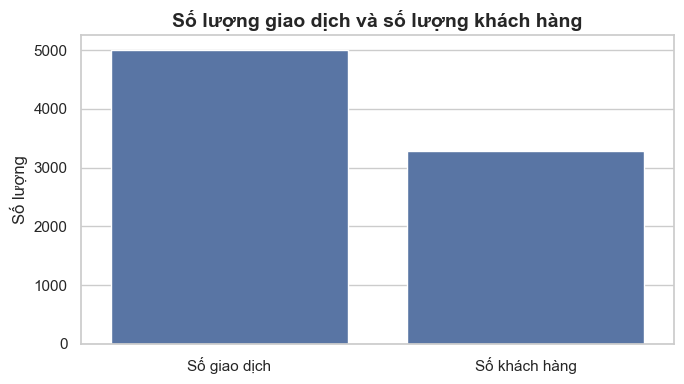

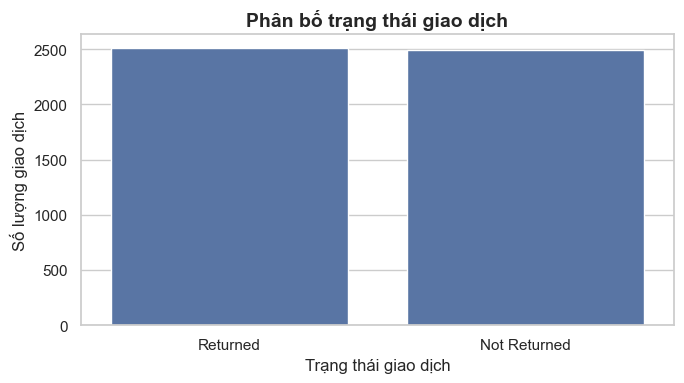

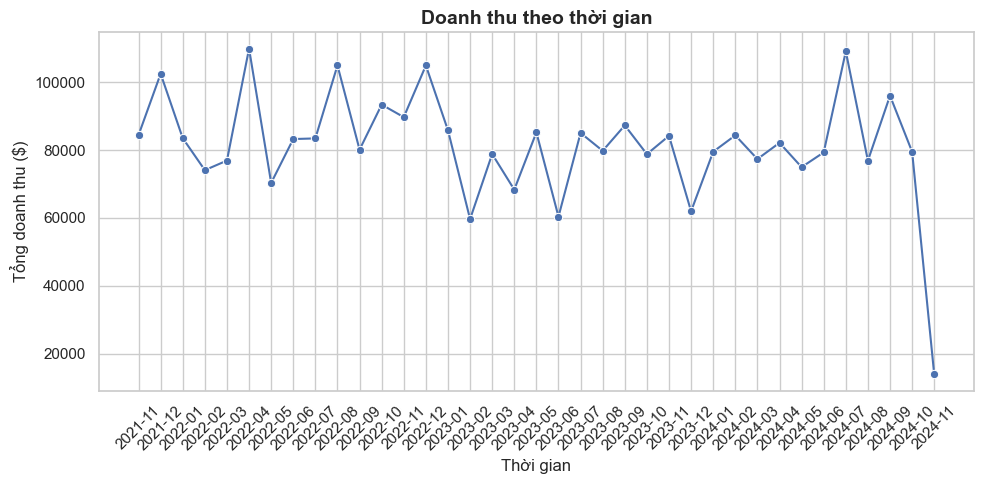

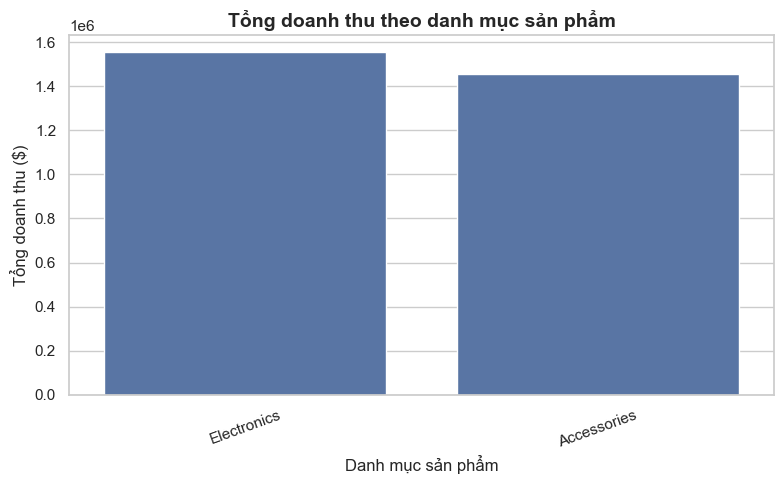

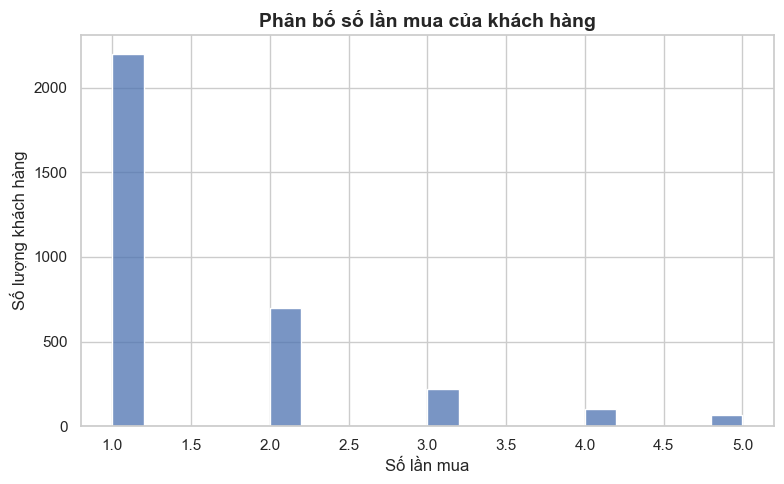

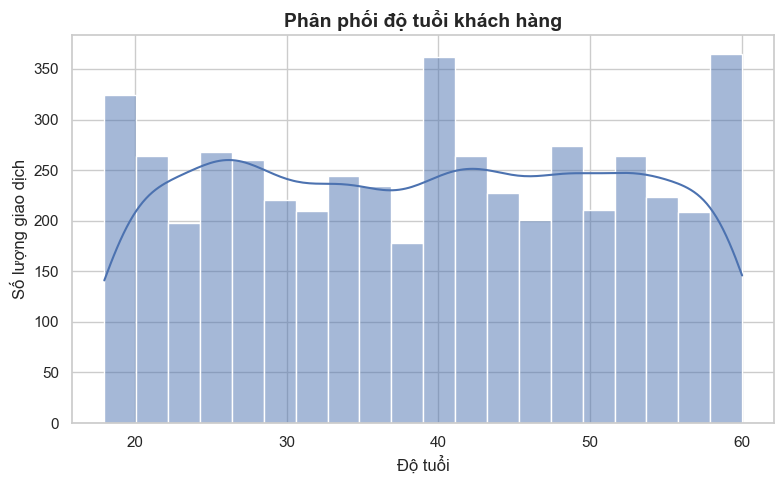


=== HOÀN TẤT EDA ===


In [18]:
#1. eda
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import urllib

# ==========================================
# 1. KẾT NỐI PYTHON VỚI SQL SERVER
# ==========================================

server_name = r'.\SQLEXPRESS'
database_name = 'khdl_project'

print(f"Đang kết nối tới SQL Server: {server_name}...")

params = urllib.parse.quote_plus(
    f'DRIVER={{ODBC Driver 17 for SQL Server}};'
    f'SERVER={server_name};'
    f'DATABASE={database_name};'
    f'UID=sa;'
    f'PWD=123456;'
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# ==========================================
# 2. TRUY VẤN DỮ LIỆU TỪ DATABASE ĐÃ CHUẨN HÓA
# ==========================================

print("Đang kéo dữ liệu bằng JOIN từ các bảng...")

query = """
SELECT 
    t.transaction_id, 
    t.date, 
    t.customer_id, 
    c.age, 
    p.category, 
    t.payment_method, 
    t.total_sale_amount, 
    t.return_status 
FROM dbo.Transactions t
JOIN dbo.Customers c ON t.customer_id = c.customer_id
JOIN dbo.Products p ON t.product_id = p.product_id;
"""

df = pd.read_sql(query, engine)
df["date"] = pd.to_datetime(df["date"])

print(f"Thành công! Đã kéo về {len(df)} dòng dữ liệu.")

# ==========================================
# 3. THỐNG KÊ TỔNG QUAN
# ==========================================

total_transactions = df["transaction_id"].nunique()
total_customers = df["customer_id"].nunique()
total_revenue = df["total_sale_amount"].sum()

print("\n===== THỐNG KÊ TỔNG QUAN =====")
print(f"Tổng số giao dịch: {total_transactions}")
print(f"Tổng số khách hàng: {total_customers}")
print(f"Tổng doanh thu: {total_revenue:,.2f}")

summary_df = pd.DataFrame({
    "Chỉ số": ["Số giao dịch", "Số khách hàng", "Tổng doanh thu"],
    "Giá trị": [total_transactions, total_customers, round(total_revenue, 2)]
})

print("\nBảng thống kê tổng quan:")
print(summary_df)

sns.set_theme(style="whitegrid")

# ==========================================
# 4. BIỂU ĐỒ 1: SỐ GIAO DỊCH VÀ SỐ KHÁCH HÀNG
# ==========================================

plt.figure(figsize=(7, 4))

overview_df = pd.DataFrame({
    "Chỉ số": ["Số giao dịch", "Số khách hàng"],
    "Số lượng": [total_transactions, total_customers]
})

sns.barplot(
    data=overview_df,
    x="Chỉ số",
    y="Số lượng"
)

plt.title("Số lượng giao dịch và số lượng khách hàng", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.show()

# ==========================================
# 5. BIỂU ĐỒ 2: PHÂN BỐ RETURNED / NOT RETURNED
# ==========================================

plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="return_status"
)

plt.title("Phân bố trạng thái giao dịch", fontsize=14, fontweight="bold")
plt.xlabel("Trạng thái giao dịch")
plt.ylabel("Số lượng giao dịch")
plt.tight_layout()
plt.show()

# ==========================================
# 6. BIỂU ĐỒ 3: DOANH THU THEO THỜI GIAN
# ==========================================

revenue_by_date = (
    df.groupby(df["date"].dt.to_period("M"))["total_sale_amount"]
    .sum()
    .reset_index()
)

revenue_by_date["date"] = revenue_by_date["date"].astype(str)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=revenue_by_date,
    x="date",
    y="total_sale_amount",
    marker="o"
)

plt.title("Doanh thu theo thời gian", fontsize=14, fontweight="bold")
plt.xlabel("Thời gian")
plt.ylabel("Tổng doanh thu ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# 7. BIỂU ĐỒ 4: DOANH THU THEO DANH MỤC SẢN PHẨM
# ==========================================

sales_by_category = (
    df.groupby("category")["total_sale_amount"]
    .sum()
    .reset_index()
    .sort_values(by="total_sale_amount", ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=sales_by_category,
    x="category",
    y="total_sale_amount"
)

plt.title("Tổng doanh thu theo danh mục sản phẩm", fontsize=14, fontweight="bold")
plt.xlabel("Danh mục sản phẩm")
plt.ylabel("Tổng doanh thu ($)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ==========================================
# 8. BIỂU ĐỒ 5: HÀNH VI MUA HÀNG CỦA KHÁCH HÀNG
#    Dựa trên số lần mua của từng khách hàng
# ==========================================

purchase_frequency = (
    df.groupby("customer_id")["transaction_id"]
    .nunique()
    .reset_index()
)

purchase_frequency.columns = ["customer_id", "purchase_count"]

plt.figure(figsize=(8, 5))

sns.histplot(
    purchase_frequency["purchase_count"],
    bins=20,
    kde=False
)

plt.title("Phân bố số lần mua của khách hàng", fontsize=14, fontweight="bold")
plt.xlabel("Số lần mua")
plt.ylabel("Số lượng khách hàng")
plt.tight_layout()
plt.show()

# ==========================================
# 9. BIỂU ĐỒ 6: PHÂN PHỐI ĐỘ TUỔI KHÁCH HÀNG
#    Có thể dùng thêm nếu muốn EDA đầy đủ hơn
# ==========================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df["age"],
    bins=20,
    kde=True
)

plt.title("Phân phối độ tuổi khách hàng", fontsize=14, fontweight="bold")
plt.xlabel("Độ tuổi")
plt.ylabel("Số lượng giao dịch")
plt.tight_layout()
plt.show()

print("\n=== HOÀN TẤT EDA ===")

=== RFM + FEATURE ENGINEERING - MEMBER 2 ===
1. Đang kết nối SQL Server và trích xuất dữ liệu...

[1] Đọc dữ liệu từ SQL thành công
Số dòng: 1986
Số cột: 15
  customer_id  Recency  Frequency  Monetary_CLV  Avg_Order_Value  \
0   CUST00130     1037          1          5.66             5.66   
1   CUST00273      198          1          9.45             9.45   
2   CUST02405      366          1          9.77             9.77   
3   CUST00785     1013          1         11.13            11.13   
4   CUST02004      479          1         12.54            12.54   

   Total_Quantity  Avg_Quantity  Customer_Lifespan  Discount_Usage_Rate  \
0               1           1.0                  0                  1.0   
1               1           1.0                  0                  1.0   
2               1           1.0                  0                  1.0   
3               1           1.0                  0                  1.0   
4               2           2.0                  0         

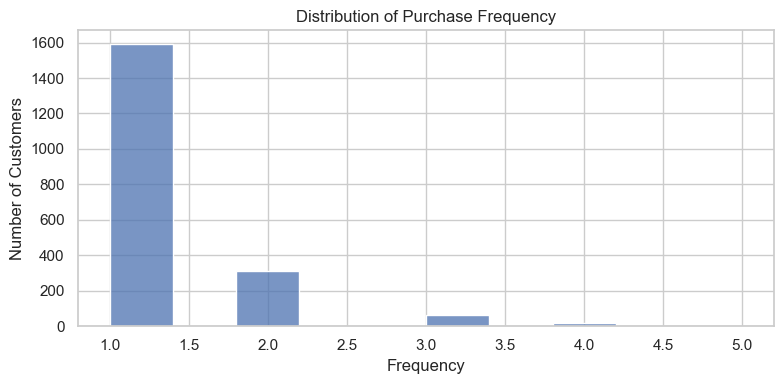

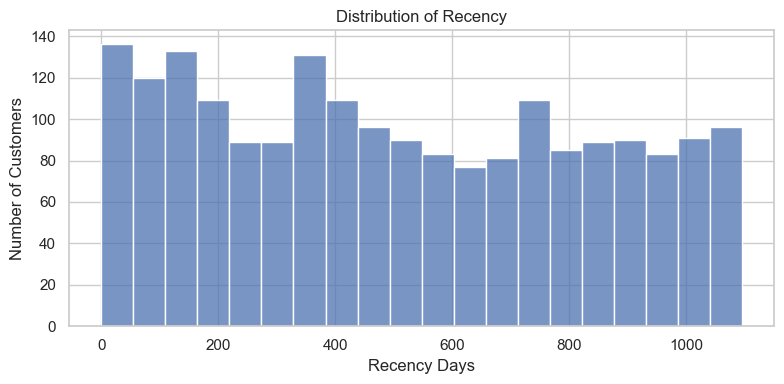

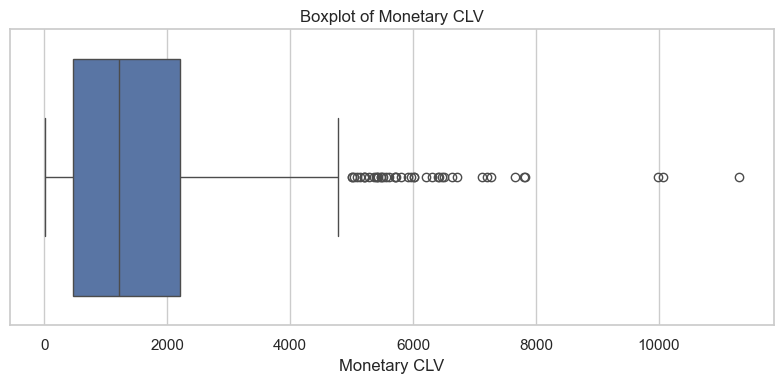

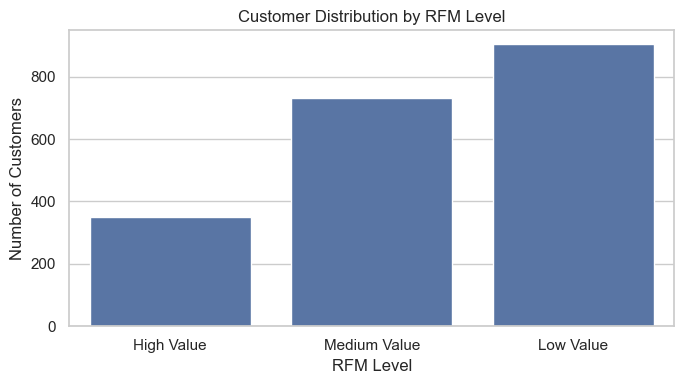

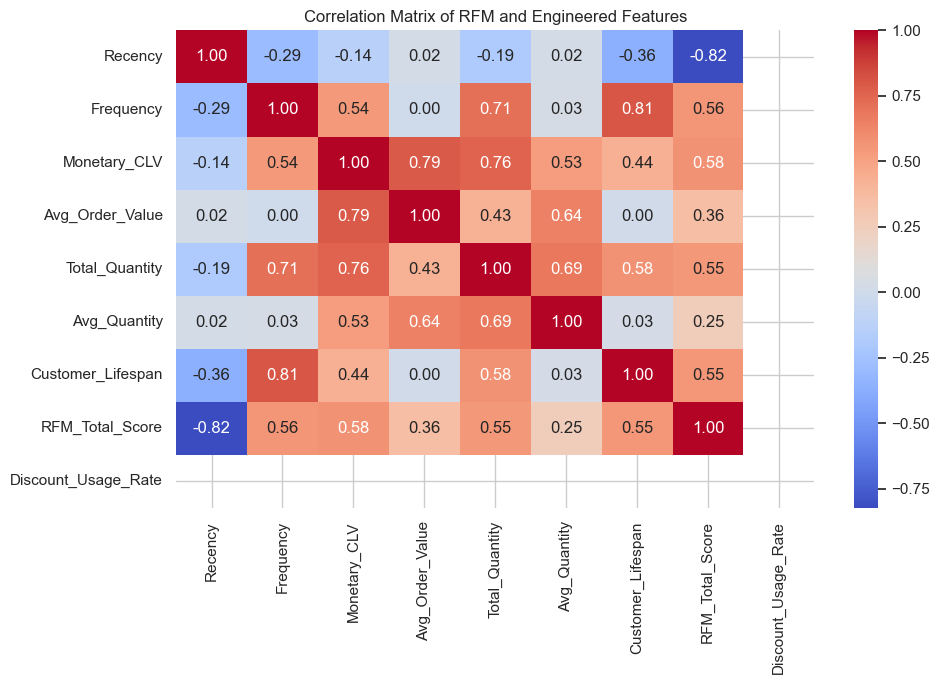

In [19]:
#2. member 2
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings

# Tắt các cảnh báo vặt của Python 
warnings.filterwarnings('ignore')

print("=== RFM + FEATURE ENGINEERING - MEMBER 2 ===")

# --- BƯỚC 1: KẾT NỐI SQL VÀ TẠO 6 BIẾN TRỰC TIẾP TỪ DATABASE ---
print("1. Đang kết nối SQL Server và trích xuất dữ liệu...")
conn_str = (
    "Driver={SQL Server};"
    "Server=.\\SQLEXPRESS;"
    "Database=khdl_project;"
    "UID=sa;"
    "PWD=123456;"
)
conn = pyodbc.connect(conn_str)

# ==============================
# 2. ĐỌC BẢNG RFM FINAL TỪ SQL
# ==============================

query = """
SELECT *
FROM Customer_RFM_Final;
"""

df = pd.read_sql(query, conn)

print("\n[1] Đọc dữ liệu từ SQL thành công")
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])
print(df.head())

# ==============================
# 3. KIỂM TRA DỮ LIỆU
# ==============================

print("\n[2] Kiểm tra missing values:")
print(df.isnull().sum())

print("\n[3] Thống kê mô tả:")
print(df.describe())

print("\n[4] Phân bố nhóm RFM:")
print(df["RFM_Level"].value_counts())

print("\n[5] Phân bố Frequency:")
print(df["Frequency"].value_counts().sort_index())

# ==============================
# 4. CHỌN FEATURE ĐỂ SCALE
# ==============================

features_to_scale = [
    "Recency",
    "Frequency",
    "Monetary_CLV",
    "Avg_Order_Value",
    "Total_Quantity",
    "Avg_Quantity",
    "Customer_Lifespan",
    "RFM_Total_Score"
]

# Nếu có Discount_Usage_Rate thì thêm vào
if "Discount_Usage_Rate" in df.columns:
    features_to_scale.append("Discount_Usage_Rate")

# ==============================
# 5. MIN-MAX SCALING
# ==============================

df_scaled = df.copy()

scaler = MinMaxScaler()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# Đảo chiều Recency để giá trị càng cao nghĩa là khách mua càng gần đây
df_scaled["Recency"] = 1 - df_scaled["Recency"]

print("\n[6] Đã chuẩn hóa Min-Max Scaling")
print(df_scaled[features_to_scale].head())

# ==============================
# 6. VẼ BIỂU ĐỒ
# ==============================

# 6.1 Histogram Frequency
plt.figure(figsize=(8, 4))
sns.histplot(df["Frequency"], bins=10)
plt.title("Distribution of Purchase Frequency")
plt.xlabel("Frequency")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# 6.2 Histogram Recency
plt.figure(figsize=(8, 4))
sns.histplot(df["Recency"], bins=20)
plt.title("Distribution of Recency")
plt.xlabel("Recency Days")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# 6.3 Boxplot Monetary CLV
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Monetary_CLV"])
plt.title("Boxplot of Monetary CLV")
plt.xlabel("Monetary CLV")
plt.tight_layout()
plt.show()

# 6.4 Countplot RFM Level
plt.figure(figsize=(7, 4))
sns.countplot(x="RFM_Level", data=df, order=["High Value", "Medium Value", "Low Value"])
plt.title("Customer Distribution by RFM Level")
plt.xlabel("RFM Level")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# 6.5 Heatmap tương quan
corr_cols = [
    "Recency",
    "Frequency",
    "Monetary_CLV",
    "Avg_Order_Value",
    "Total_Quantity",
    "Avg_Quantity",
    "Customer_Lifespan",
    "RFM_Total_Score"
]

if "Discount_Usage_Rate" in df.columns:
    corr_cols.append("Discount_Usage_Rate")

plt.figure(figsize=(10, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of RFM and Engineered Features")
plt.tight_layout()
plt.show()

=== K-MEANS CLUSTERING VISUALIZATION 3D ===

Đọc dữ liệu thành công: 1986 khách hàng, 15 cột.

Các feature dùng cho K-Means:
['Recency', 'Frequency', 'Avg_Quantity', 'Customer_Lifespan', 'Discount_Usage_Rate']

Đã chuẩn hóa dữ liệu về khoảng 0–1.

Đang vẽ Elbow Method...


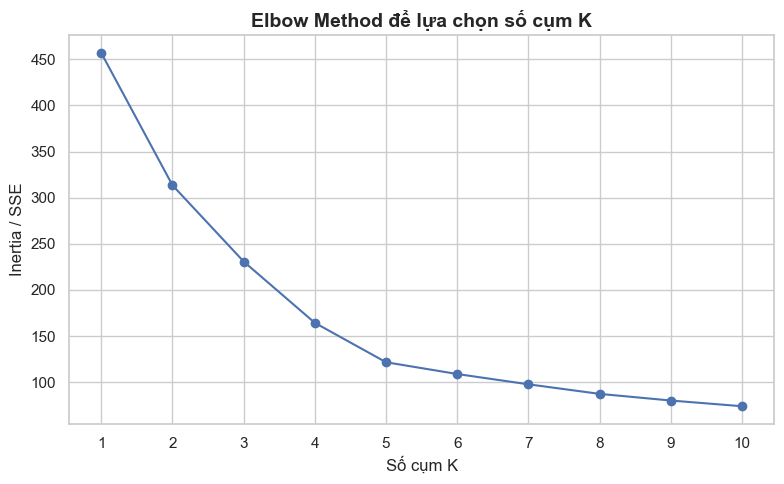


Đang chạy K-Means với K = 3...

Phân bố khách hàng theo cụm:
ML_Cluster
0    887
1    826
2    273
Name: count, dtype: int64


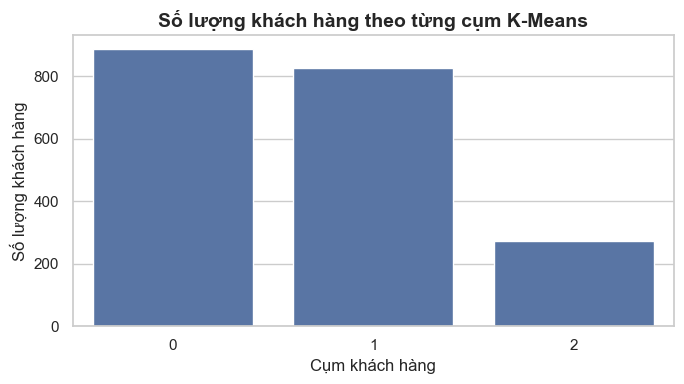


Đang giảm chiều dữ liệu bằng PCA 3D...

Tỷ lệ phương sai được giải thích bởi từng PCA component:
[0.43685581 0.36079138 0.18041917]
Tổng tỷ lệ phương sai được giải thích bởi 3 component:
0.9781


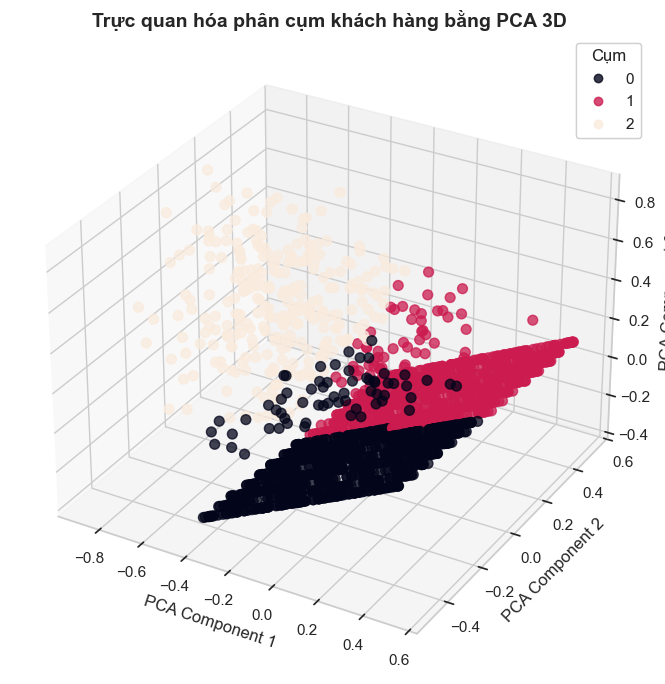


Đặc điểm trung bình của từng cụm trên dữ liệu gốc:
 ML_Cluster    Recency  Frequency  Avg_Quantity  Customer_Lifespan  Discount_Usage_Rate
          0 533.941375   1.073281      4.384066          11.567080                  1.0
          1 586.280872   1.076271     11.574455          11.233656                  1.0
          2 206.864469   2.380952      8.164347         558.131868                  1.0

Phân bố khách hàng theo cụm:
ML_Cluster
0    887
1    826
2    273
Name: count, dtype: int64


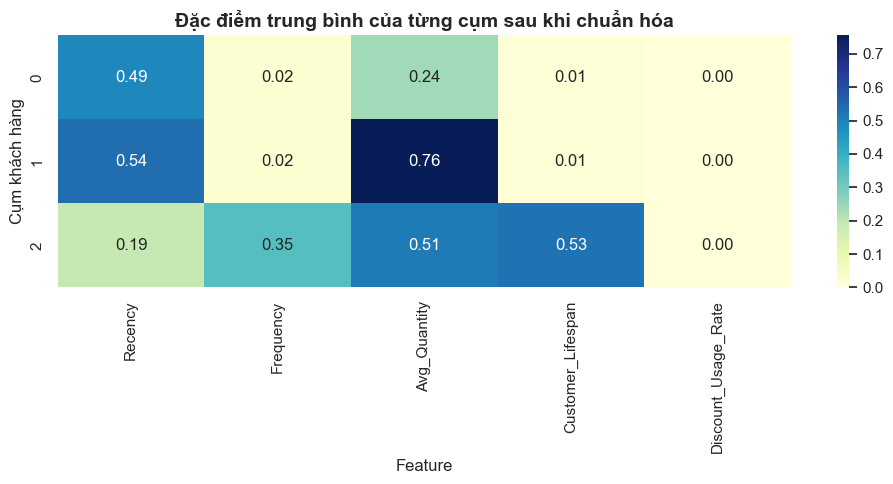


Đã lưu kết quả phân cụm vào file: customer_clusters_result.csv

=== HOÀN TẤT K-MEANS VISUALIZATION 3D ===


In [20]:
#3. kmeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import warnings

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


# =========================================================
# 1. KẾT NỐI SQL SERVER VÀ ĐỌC DỮ LIỆU
# =========================================================

print("=== K-MEANS CLUSTERING VISUALIZATION 3D ===\n")

conn_str = (
    "Driver={SQL Server};"
    "Server=.\\SQLEXPRESS;"
    "Database=khdl_project;"
    "UID=sa;"
    "PWD=123456;"
)

query = """
SELECT *
FROM Customer_RFM_Final;
"""

try:
    conn = pyodbc.connect(conn_str)
    df = pd.read_sql(query, conn)
    conn.close()

    print(f"Đọc dữ liệu thành công: {df.shape[0]} khách hàng, {df.shape[1]} cột.")
except Exception as e:
    print("Lỗi kết nối SQL:", e)
    exit()


# =========================================================
# 2. CHỌN FEATURE CHO K-MEANS
# =========================================================

cluster_features = [
    "Recency",
    "Frequency",
    "Avg_Quantity",
    "Customer_Lifespan"
]

# Nếu có Discount_Usage_Rate thì thêm vào
if "Discount_Usage_Rate" in df.columns:
    cluster_features.append("Discount_Usage_Rate")

missing_cols = [col for col in cluster_features if col not in df.columns]

if missing_cols:
    print("Thiếu cột dùng cho K-Means:", missing_cols)
    exit()

print("\nCác feature dùng cho K-Means:")
print(cluster_features)


# =========================================================
# 3. SCALE DỮ LIỆU
# =========================================================

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[cluster_features])

df_scaled = pd.DataFrame(
    X_scaled,
    columns=cluster_features
)

print("\nĐã chuẩn hóa dữ liệu về khoảng 0–1.")


# =========================================================
# 4. ELBOW METHOD - GIẢI THÍCH CHỌN K
# =========================================================

print("\nĐang vẽ Elbow Method...")

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    list(K_range),
    inertias,
    marker="o"
)

plt.title("Elbow Method để lựa chọn số cụm K", fontsize=14, fontweight="bold")
plt.xlabel("Số cụm K")
plt.ylabel("Inertia / SSE")
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


# =========================================================
# 5. CHẠY K-MEANS VỚI K = 3
# =========================================================

print("\nĐang chạy K-Means với K = 3...")

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["ML_Cluster"] = kmeans.fit_predict(X_scaled)
df_scaled["ML_Cluster"] = df["ML_Cluster"]

print("\nPhân bố khách hàng theo cụm:")
print(df["ML_Cluster"].value_counts().sort_index())


# =========================================================
# 6. BIỂU ĐỒ SỐ LƯỢNG KHÁCH HÀNG THEO CỤM
# =========================================================

plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="ML_Cluster",
    order=sorted(df["ML_Cluster"].unique())
)

plt.title("Số lượng khách hàng theo từng cụm K-Means", fontsize=14, fontweight="bold")
plt.xlabel("Cụm khách hàng")
plt.ylabel("Số lượng khách hàng")
plt.tight_layout()
plt.show()


# =========================================================
# 7. PCA 3D - TRỰC QUAN HÓA CỤM KHÁCH HÀNG
# =========================================================

print("\nĐang giảm chiều dữ liệu bằng PCA 3D...")

pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_scaled)

df_pca_3d = pd.DataFrame({
    "PCA_1": pca_result[:, 0],
    "PCA_2": pca_result[:, 1],
    "PCA_3": pca_result[:, 2],
    "ML_Cluster": df["ML_Cluster"]
})

print("\nTỷ lệ phương sai được giải thích bởi từng PCA component:")
print(pca.explained_variance_ratio_)

print("Tổng tỷ lệ phương sai được giải thích bởi 3 component:")
print(round(pca.explained_variance_ratio_.sum(), 4))


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df_pca_3d["PCA_1"],
    df_pca_3d["PCA_2"],
    df_pca_3d["PCA_3"],
    c=df_pca_3d["ML_Cluster"],
    s=50,
    alpha=0.75
)

ax.set_title(
    "Trực quan hóa phân cụm khách hàng bằng PCA 3D",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")

legend = ax.legend(
    *scatter.legend_elements(),
    title="Cụm"
)

ax.add_artist(legend)

plt.tight_layout()
plt.show()


# =========================================================
# 8. CLUSTER PROFILE - ĐẶC ĐIỂM TRUNG BÌNH TỪNG CỤM
# =========================================================

cluster_profile = (
    df.groupby("ML_Cluster")[cluster_features]
    .mean()
    .reset_index()
)

print("\nĐặc điểm trung bình của từng cụm trên dữ liệu gốc:")
print(cluster_profile.to_string(index=False))

df["ML_Cluster"] = kmeans.fit_predict(X_scaled)
df_scaled["ML_Cluster"] = df["ML_Cluster"]

print("\nPhân bố khách hàng theo cụm:")
print(df["ML_Cluster"].value_counts().sort_index())

# Dùng dữ liệu đã scale để heatmap dễ so sánh hơn
cluster_profile_scaled = (
    df_scaled.groupby("ML_Cluster")[cluster_features]
    .mean()
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title(
    "Đặc điểm trung bình của từng cụm sau khi chuẩn hóa",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Feature")
plt.ylabel("Cụm khách hàng")
plt.tight_layout()
plt.show()


# =========================================================
# 9. LƯU KẾT QUẢ PHÂN CỤM
# =========================================================

output_file = "customer_clusters_result.csv"

df.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print(f"\nĐã lưu kết quả phân cụm vào file: {output_file}")
print("\n=== HOÀN TẤT K-MEANS VISUALIZATION 3D ===")

In [2]:
#4. model
import pandas as pd
import numpy as np
import pyodbc
import warnings

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")


# =========================================================
# 1. KẾT NỐI SQL SERVER VÀ ĐỌC BẢNG CUSTOMER_RFM_FINAL
# =========================================================

print("=== CLV MODEL PIPELINE: SCALING + CLUSTERING + TUNED MODEL ===\n")

conn_str = (
    "Driver={SQL Server};"
    "Server=.\\SQLEXPRESS;"
    "Database=khdl_project;"
    "UID=sa;"
    "PWD=123456;"
)

query = """
SELECT *
FROM Customer_RFM_Final;
"""

try:
    conn = pyodbc.connect(conn_str)
    df = pd.read_sql(query, conn)
    conn.close()

    print(f"Đọc dữ liệu thành công: {df.shape[0]} khách hàng, {df.shape[1]} cột.")
except Exception as e:
    print("Lỗi kết nối hoặc đọc dữ liệu SQL:", e)
    exit()


# =========================================================
# 3. SCALE DỮ LIỆU CHO K-MEANS CLUSTERING
# =========================================================

print("\n[1] Đang chuẩn hóa dữ liệu cho K-Means...")

cluster_features = [
    "Recency",
    "Frequency",
    "Avg_Quantity",
    "Customer_Lifespan"
]

if "Discount_Usage_Rate" in df.columns:
    cluster_features.append("Discount_Usage_Rate")

missing_cluster_cols = [col for col in cluster_features if col not in df.columns]

if missing_cluster_cols:
    print("Thiếu các cột dùng cho clustering:", missing_cluster_cols)
    exit()

scaler_cluster = MinMaxScaler()
X_cluster_scaled = scaler_cluster.fit_transform(df[cluster_features])

print("Đã scale dữ liệu clustering về khoảng 0–1.")
print("Feature dùng cho clustering:")
print(cluster_features)


# =========================================================
# 4. K-MEANS CLUSTERING
# =========================================================

print("\n[2] Đang phân cụm khách hàng bằng K-Means...")

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["ML_Cluster"] = kmeans.fit_predict(X_cluster_scaled)

print("Đã tạo cột ML_Cluster.")
print("\nPhân bố khách hàng theo cụm:")
print(df["ML_Cluster"].value_counts().sort_index())


# =========================================================
# 5. CHUẨN BỊ DỮ LIỆU CHO MODEL
# =========================================================

print("\n[3] Đang chuẩn bị dữ liệu train model...")

drop_cols = [
    # ID khách hàng
    "CustomerID",
    "Customer_ID",
    "customer_id",

    # Target cần dự đoán
    "Monetary_CLV",

    # Biến có nguy cơ data leakage
    "RFM_Total_Score",
    "RFM_Level",
    "RFM_Code",
    "R_Score",
    "F_Score",
    "M_Score",

    # Biến liên quan trực tiếp đến Monetary_CLV
    "Avg_Order_Value",
    "Total_Quantity",

    # 3 feature mới đã thử nhưng không dùng trong bản cuối
    "Return_Rate",
    "Category_Count",
    "Avg_Days_Between_Purchases"
]

df_model = df.copy()

# One-hot encoding cho ML_Cluster
df_model = pd.get_dummies(
    df_model,
    columns=["ML_Cluster"],
    drop_first=True
)

if "Monetary_CLV" not in df_model.columns:
    print("Không tìm thấy cột Monetary_CLV.")
    exit()

# X là feature đầu vào
X = df_model.drop(columns=[col for col in drop_cols if col in df_model.columns])

# Chỉ giữ cột số
X = X.select_dtypes(include=[np.number])

# y là target
y = df_model["Monetary_CLV"]

# Log transform target để giảm lệch phân phối tiền
y_log = np.log1p(y)

print("\nCác feature được dùng để train model:")
print(list(X.columns))
print("Số lượng feature đầu vào:", X.shape[1])


# =========================================================
# 6. TRAIN / TEST SPLIT
# =========================================================

print("\n[4] Đang chia dữ liệu train/test...")

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

print(f"Train size: {X_train.shape[0]} mẫu")
print(f"Test size: {X_test.shape[0]} mẫu")


# =========================================================
# 7. SCALE SAU KHI CHIA TRAIN/TEST
# =========================================================

print("\n[5] Đang scale dữ liệu train/test...")

scaler_final = MinMaxScaler()

X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

print("Đã scale đúng cách: fit trên train, transform trên test.")


# =========================================================
# 8. TỐI ƯU THAM SỐ MODEL BẰNG GRID SEARCH
# =========================================================

print("\n[6] Đang tối ưu tham số các mô hình bằng Grid Search + Cross Validation...")

# -----------------------------
# Random Forest
# -----------------------------

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train_log)
best_random_forest = rf_grid.best_estimator_

print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)
print("Best Random Forest CV R²:", round(rf_grid.best_score_, 4))


# -----------------------------
# Gradient Boosting
# -----------------------------

gb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.1],
    "min_samples_leaf": [1, 2]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(X_train_scaled, y_train_log)
best_gradient_boosting = gb_grid.best_estimator_

print("\nBest Gradient Boosting Parameters:")
print(gb_grid.best_params_)
print("Best Gradient Boosting CV R²:", round(gb_grid.best_score_, 4))


# -----------------------------
# Extra Trees
# -----------------------------

et_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [6, 8, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4]
}

et_grid = GridSearchCV(
    estimator=ExtraTreesRegressor(random_state=42),
    param_grid=et_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

et_grid.fit(X_train_scaled, y_train_log)
best_extra_trees = et_grid.best_estimator_

print("\nBest Extra Trees Parameters:")
print(et_grid.best_params_)
print("Best Extra Trees CV R²:", round(et_grid.best_score_, 4))


# Bảng tổng hợp tham số tối ưu
best_params_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "Extra Trees"
    ],
    "Best Parameters": [
        str(rf_grid.best_params_),
        str(gb_grid.best_params_),
        str(et_grid.best_params_)
    ],
    "Best CV R-squared": [
        round(rf_grid.best_score_, 4),
        round(gb_grid.best_score_, 4),
        round(et_grid.best_score_, 4)
    ]
})

print("\nBẢNG THAM SỐ TỐI ƯU:")
print(best_params_df.to_string(index=False))


# =========================================================
# 9. TRAIN VÀ ĐÁNH GIÁ CÁC MODEL ĐÃ TỐI ƯU
# =========================================================

print("\n[7] Đang train và đánh giá model trên tập test...")

models = {
    "Random Forest - Tuned": best_random_forest,
    "Gradient Boosting - Tuned": best_gradient_boosting,
    "Extra Trees - Tuned": best_extra_trees,
    "Linear Regression": LinearRegression()
}

results = []
predictions_store = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_log)

    y_pred_log = model.predict(X_test_scaled)

    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test_log)

    r2 = r2_score(y_test_real, y_pred_real)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

    results.append({
        "Model": name,
        "R-squared": round(r2, 4),
        "RMSE ($)": round(rmse, 2),
        "MAE ($)": round(mae, 2)
    })

    predictions_store[name] = pd.DataFrame({
        "Actual_CLV": y_test_real,
        "Predicted_CLV": y_pred_real
    })


results_df = pd.DataFrame(results).sort_values(
    by="R-squared",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("BẢNG TỔNG KẾT SAI SỐ CÁC MÔ HÌNH")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

best_model = results_df.iloc[0]

print("\nMô hình tốt nhất:")
print(f"- {best_model['Model']}")
print(f"- R-squared: {best_model['R-squared']}")
print(f"- RMSE ($): {best_model['RMSE ($)']}")
print(f"- MAE ($): {best_model['MAE ($)']}")


# =========================================================
# 10. FEATURE IMPORTANCE CỦA EXTRA TREES
# =========================================================

print("\n[8] Mức độ quan trọng của feature trong Extra Trees Tuned:")

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_extra_trees.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.to_string(index=False))


# =========================================================
# LƯU KẾT QUẢ MODEL CHO NGƯỜI 4 ĐÁNH GIÁ
# =========================================================

results_df.to_csv(
    "model_evaluation_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nĐã lưu bảng kết quả model vào: model_evaluation_results.csv")

for model_name, pred_df in predictions_store.items():
    safe_name = (
        model_name
        .replace(" ", "_")
        .replace("-", "")
        .replace("/", "")
    )

    file_name = f"predictions_{safe_name}.csv"

    pred_df.to_csv(
        file_name,
        index=False,
        encoding="utf-8-sig"
    )

    print(f"Đã lưu dự đoán của {model_name} vào: {file_name}")

=== CLV MODEL PIPELINE: SCALING + CLUSTERING + TUNED MODEL ===

Đọc dữ liệu thành công: 1986 khách hàng, 15 cột.

[1] Đang chuẩn hóa dữ liệu cho K-Means...
Đã scale dữ liệu clustering về khoảng 0–1.
Feature dùng cho clustering:
['Recency', 'Frequency', 'Avg_Quantity', 'Customer_Lifespan', 'Discount_Usage_Rate']

[2] Đang phân cụm khách hàng bằng K-Means...
Đã tạo cột ML_Cluster.

Phân bố khách hàng theo cụm:
ML_Cluster
0    887
1    826
2    273
Name: count, dtype: int64

[3] Đang chuẩn bị dữ liệu train model...

Các feature được dùng để train model:
['Recency', 'Frequency', 'Avg_Quantity', 'Customer_Lifespan', 'Discount_Usage_Rate']
Số lượng feature đầu vào: 5

[4] Đang chia dữ liệu train/test...
Train size: 1588 mẫu
Test size: 398 mẫu

[5] Đang scale dữ liệu train/test...
Đã scale đúng cách: fit trên train, transform trên test.

[6] Đang tối ưu tham số các mô hình bằng Grid Search + Cross Validation...

Best Random Forest Parameters:
{'max_depth': 4, 'min_samples_leaf': 1, 'min_sampl

BẢNG KẾT QUẢ MODEL:
                    Model  R-squared  RMSE ($)  MAE ($)
      Extra Trees - Tuned     0.5046    912.47   683.91
    Random Forest - Tuned     0.4977    918.75   688.88
Gradient Boosting - Tuned     0.4881    927.54   693.16
        Linear Regression     0.3910   1011.69   732.48

Mô hình tốt nhất:
- Extra Trees - Tuned
- R-squared: 0.5046
- RMSE ($): 912.47
- MAE ($): 683.91


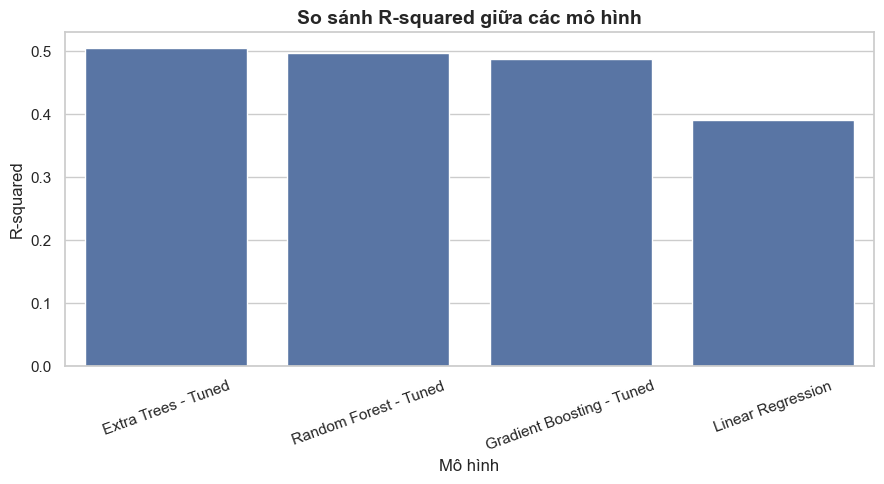

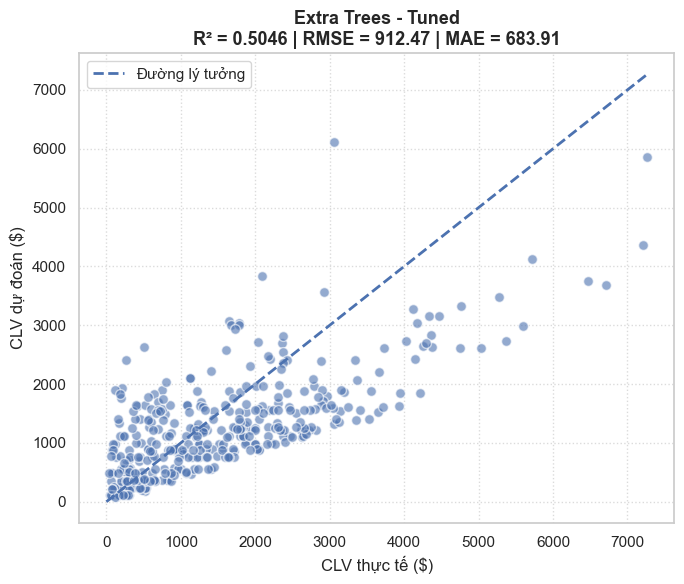

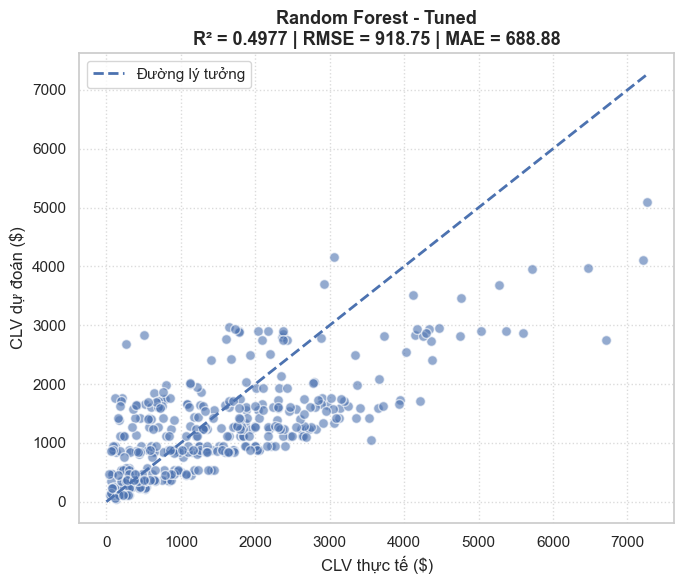

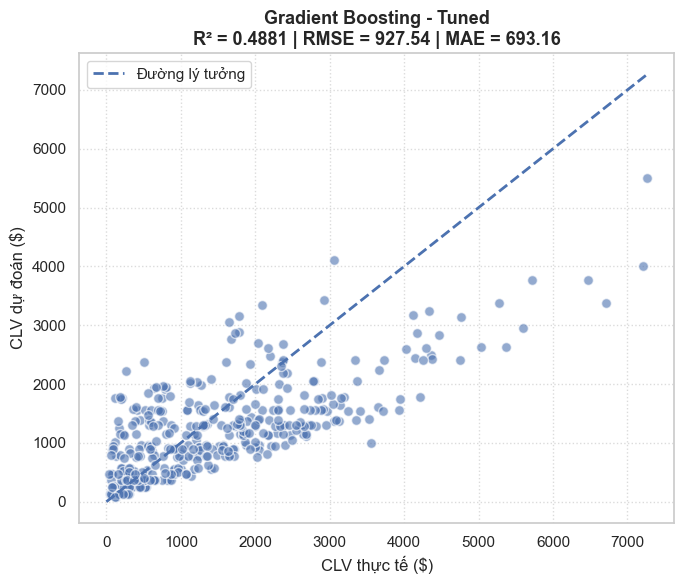

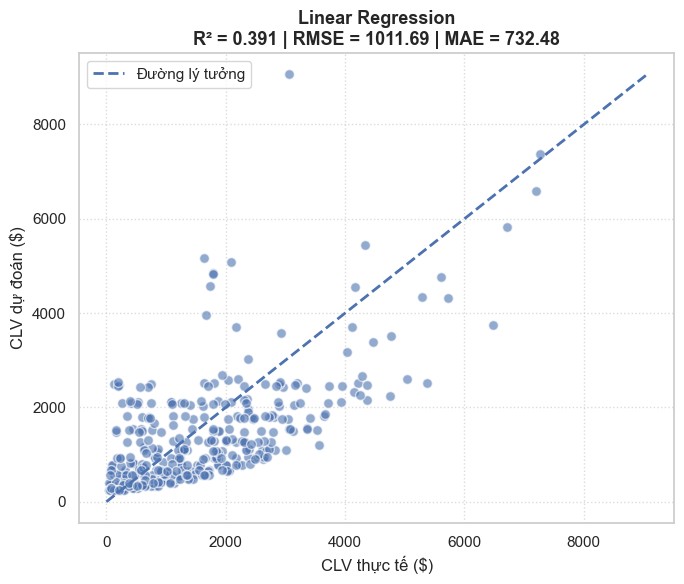


=== HOÀN TẤT PHẦN ĐÁNH GIÁ MODEL CỦA NGƯỜI 4 ===


In [1]:
#5. Biểu đồ
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# =========================================================
# 1. ĐỌC BẢNG KẾT QUẢ MODEL TỪ NGƯỜI 3
# =========================================================

results_df = pd.read_csv("model_evaluation_results.csv")

print("BẢNG KẾT QUẢ MODEL:")
print(results_df.to_string(index=False))

best_model = results_df.iloc[0]

print("\nMô hình tốt nhất:")
print(f"- {best_model['Model']}")
print(f"- R-squared: {best_model['R-squared']}")
print(f"- RMSE ($): {best_model['RMSE ($)']}")
print(f"- MAE ($): {best_model['MAE ($)']}")


# =========================================================
# 2. VẼ BIỂU ĐỒ SO SÁNH R-SQUARED
# =========================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R-squared"
)

plt.title("So sánh R-squared giữa các mô hình", fontsize=14, fontweight="bold")
plt.xlabel("Mô hình")
plt.ylabel("R-squared")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# =========================================================
# 3. VẼ ACTUAL VS PREDICTED CHO TỪNG MODEL
# =========================================================

for _, row in results_df.iterrows():
    model_name = row["Model"]
    r2 = row["R-squared"]
    rmse = row["RMSE ($)"]
    mae = row["MAE ($)"]

    safe_name = (
        model_name
        .replace(" ", "_")
        .replace("-", "")
        .replace("/", "")
    )

    file_name = f"predictions_{safe_name}.csv"

    try:
        pred_df = pd.read_csv(file_name)
    except FileNotFoundError:
        print(f"Không tìm thấy file: {file_name}")
        continue

    plt.figure(figsize=(7, 6))

    plt.scatter(
        pred_df["Actual_CLV"],
        pred_df["Predicted_CLV"],
        alpha=0.6,
        edgecolor="white",
        s=50
    )

    max_val = max(
        pred_df["Actual_CLV"].max(),
        pred_df["Predicted_CLV"].max()
    )

    plt.plot(
        [0, max_val],
        [0, max_val],
        linestyle="--",
        linewidth=2,
        label="Đường lý tưởng"
    )

    plt.title(
        f"{model_name}\nR² = {r2} | RMSE = {rmse} | MAE = {mae}",
        fontsize=13,
        fontweight="bold"
    )

    plt.xlabel("CLV thực tế ($)")
    plt.ylabel("CLV dự đoán ($)")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.tight_layout()
    plt.show()


print("\n=== HOÀN TẤT PHẦN ĐÁNH GIÁ MODEL CỦA NGƯỜI 4 ===")